## 데이터 전처리
- 데이터를 분석하기 좋은 형태로 가공하는 과정
- 원본 데이터를 그대로 사용하는 것이 아니라 이상치, 중복데이터, 결측치 등을 처리해서 신뢰할 수 있는 데이터로 만드는 과정을 의미

## 이상치(outlier)
- 관측하거나 수집한 데이터의 범위(군집)에서 많이 벗어나있는 아주 작은 값 또는 큰 값을 의미
- 이상치는 제거하거나 대체하거나 또는 가만히 놔두어도 상관없는지를 판단하여 전처리를 진행

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRuY-LwTufVlKJ-r54472gZtIxK7CuP0Ei6gVwSRUy8zWdl1koZIG6VzpR6&s=10" />

## 예측
- 숫자로 알기 힘든 값들을 표현하기 위해 기술통계량을 확인하는 것을 의미
- 알기 힘든 값들을 표현하기 위해 기술통계량을 확인하는 것을 의미

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 맥 애플고딕 설정
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [5]:
height_list = [181, 280, 158, 110, 170, 160, 155, 145]
avg_height = sum(height_list) / len(height_list)

print(f"평균 키: {avg_height}cm")
print(f"최소 키: {min(height_list)}cm")
print(f"최대 키: {max(height_list)}cm")

평균 키: 169.875cm
최소 키: 110cm
최대 키: 280cm


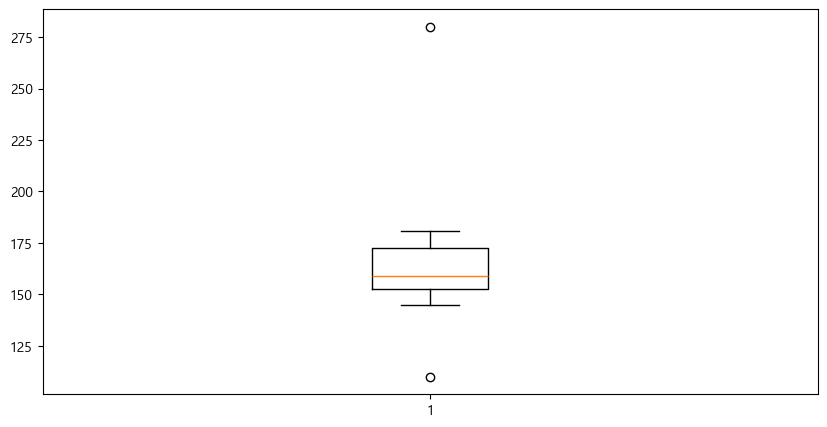

In [6]:
plt.figure(figsize=(10, 5))

# 박스플롯 이상치 탐지
plt.boxplot(height_list)
plt.show()

## 박스 플롯
- 이상치 탐색을 위해 사용되는 시각화 타츠
- 분위수를 기준으로 그려지고, 상자 안에 그려져 있는 직선이 중위수(Median)을 나타냄
- Median값의 위치에 따라 값들의 분포를 확인할 수 있다.
- 상자의 밑변은 1분위수이고, 윗변은 3분위수를 의미한다.
- 상자의 중심으로 위 아래에 직선이 있는 것을 볼 수 있는데 이 것을 울타리라고 부른다.

## 이상치 계산 공식
- 아래 이상치 Q1 - 1.5 * IQR
- 위 이상치 Q3 + 1.5 * IQR

<img style="width:500px;" src="https://blog.kakaocdn.net/dna/dLPevN/btq1caAZMWD/AAAAAAAAAAAAAAAAAAAAACdUyXIwIBA0UI-lNOxgEND-ivrCO7oAkDQNWYlbYDTf/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=o4DIu2hQNUV89WOVQAkr5VNdrvg%3D" />

In [8]:
height_list = [181, 158, 170, 160, 155, 145]
avg_height = sum(height_list) / len(height_list)

print(f"평균 키: {avg_height}cm")
print(f"최소 키: {min(height_list)}cm")
print(f"최대 키: {max(height_list)}cm")

평균 키: 161.5cm
최소 키: 145cm
최대 키: 181cm


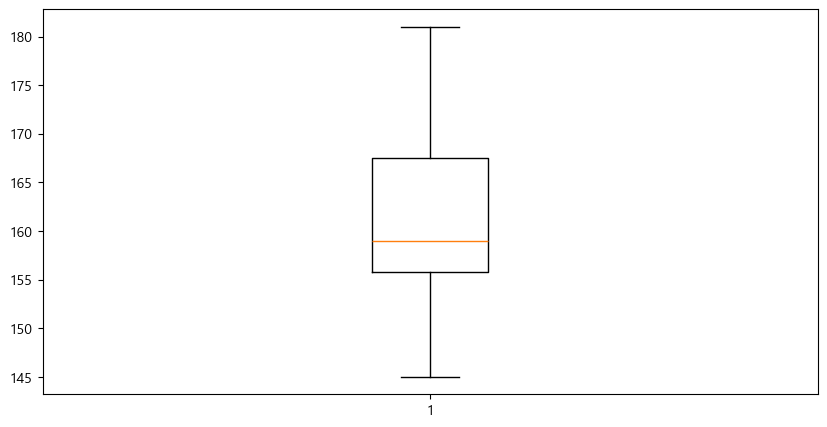

In [9]:
plt.figure(figsize=(10, 5))

# 박스플롯 이상치 탐지
plt.boxplot(height_list)
plt.show()

## 이상치(Outlier) 처리 방법
1. 값을 그대로 냅둔다.
2. 값을 제거 하는 방법(신뢰도 저하, 데이터 버려지는 단점이 있다.)

## 결측치(Outlier) 처리 방법
- 데이터 수집 또는 데이터셋에서 NULL, NaN 값이 들어가 비어있는 상태를 의미한다.
- 데이터를 수집하는 과정에서 오류, 누락, 값을 저장하는 과정에서 소실한 것을 의미하며, 분석전에 반드시 처리해야 한다.
- 대체한다면 평균값, 최빈값, 중앙값 같은 통계 수치나 머신러닝의 예측 값 중 적절한 데이터의 특성을 고려하여 대체해야 한다.

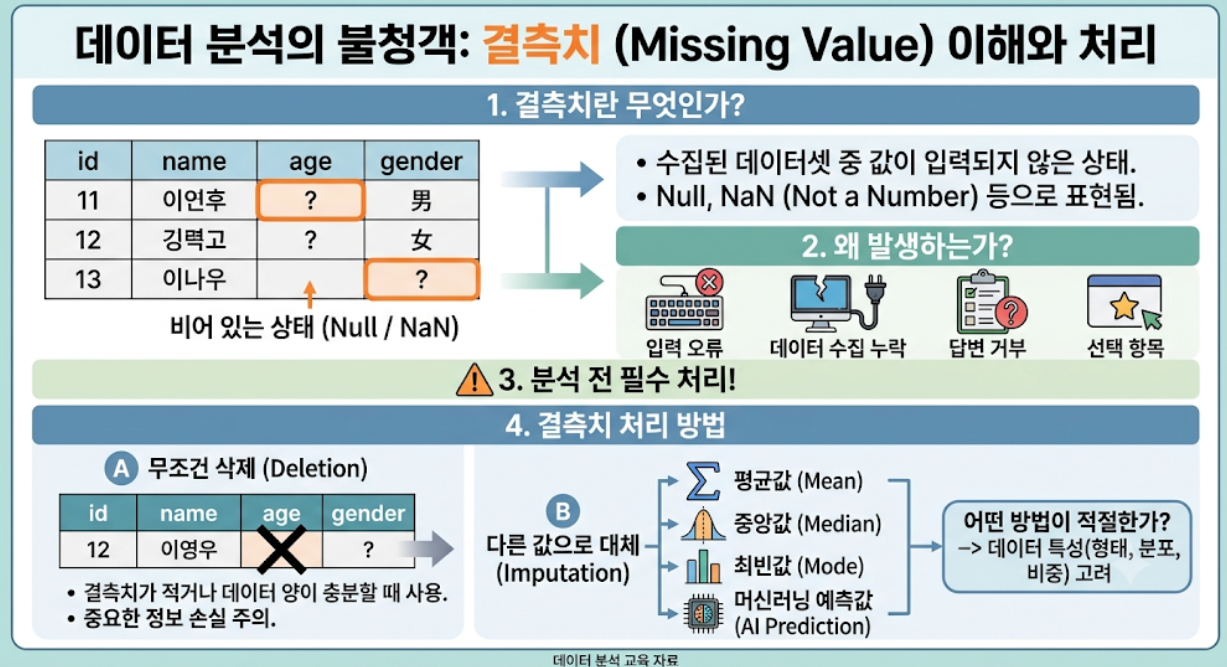

In [33]:
df = pd.DataFrame({
    "이름": ["시츄", "하아", "승연", "지성", "혜지", "승기", "우연", "소민"],
    "소득": [1000000, 55000, None, None, 100000, 50000, 3000, 50000]
})

df

,이름,소득
0,시츄,1000000.0
1,하아,55000.0
2,승연,NaN
3,지성,NaN
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


In [34]:
df.isna().sum()

이름    0
소득    2
dtype: int64

In [35]:
df2 = df.dropna()
df2

,이름,소득
0,시츄,1000000.0
1,하아,55000.0
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


# 평균값

In [36]:
df["소득"].mean()

209666.66666666666

In [37]:
# fillna: 비어있는 값에 뭘 넣을 건지
df.fillna(df["소득"].mean())

,이름,소득
0,시츄,1000000.000000
1,하아,55000.000000
2,승연,209666.666667
3,지성,209666.666667
4,혜지,100000.000000
5,승기,50000.000000
6,우연,3000.000000
7,소민,50000.000000


# 최빈값

In [38]:
df["소득"].mode()[0]

50000.0

In [39]:
df.fillna(df["소득"].mode()[0])

,이름,소득
0,시츄,1000000.0
1,하아,55000.0
2,승연,50000.0
3,지성,50000.0
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


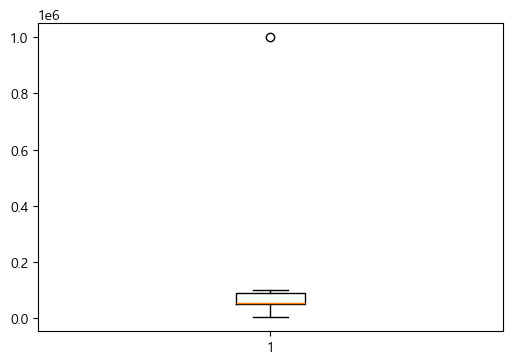

In [40]:
plt.figure(figsize=(6, 4))
plt.boxplot(df2["소득"])

plt.show()

In [41]:
df["소득"].median()

52500.0

In [43]:
df.fillna(df["소득"].median())

,이름,소득
0,시츄,1000000.0
1,하아,55000.0
2,승연,52500.0
3,지성,52500.0
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


## 중복 데이터
- 동일한 데이터가 여러 번 저장된 상태를 의미한다.
- 중복 데이터가 많아지면 통계 결과와 왜곡된 분석 결과 및 신뢰도가 떨어질 수 있다.

<img src="https://drive.google.com/thumbnail?id=1OyllE-RqUt-47NRgJ0N2oyXHKrvic3db&sz=w1000" width=1000>

In [44]:
df = pd.DataFrame({
    "이름": ["지호", "승현", "상아", "우영", "우영", "준승", "예나", "수민", "지호", "상아"],
    "취미": ["코딩", "칵테일", "알바", "코딩", "코딩", "코딩", "코딩", "스트레칭", "코딩", "알바"]
})

df

,이름,취미
0,지호,코딩
1,승현,칵테일
2,상아,알바
3,우영,코딩
4,우영,코딩
5,준승,코딩
6,예나,코딩
7,수민,스트레칭
8,지호,코딩
9,상아,알바


In [47]:
df.duplicated()

0    False
1    False
2    False
3    False
4     True
5    False
6    False
7    False
8     True
9     True
dtype: bool

In [45]:
df.duplicated().sum()

3

In [46]:
df2 = df.drop_duplicates()
df2

,이름,취미
0,지호,코딩
1,승현,칵테일
2,상아,알바
3,우영,코딩
5,준승,코딩
6,예나,코딩
7,수민,스트레칭


In [48]:
df = pd.DataFrame({
    "학번": [i + 1 for i in range(10)],
    "이름": ["지호", "승현", "상아", "우영", "우영", "준승", "예나", "수민", "지호", "상아"],
    "취미": ["코딩", "칵테일", "알바", "코딩", "코딩", "코딩", "코딩", "스트레칭", "코딩", "알바"]
})

df

,학번,이름,취미
0,1,지호,코딩
1,2,승현,칵테일
2,3,상아,알바
3,4,우영,코딩
4,5,우영,코딩
5,6,준승,코딩
6,7,예나,코딩
7,8,수민,스트레칭
8,9,지호,코딩
9,10,상아,알바


In [49]:
df.duplicated(subset=["이름", "취미"])

0    False
1    False
2    False
3    False
4     True
5    False
6    False
7    False
8     True
9     True
dtype: bool

In [51]:
df2 = df.drop_duplicates(subset=["이름", "취미"])
df2

,학번,이름,취미
0,1,지호,코딩
1,2,승현,칵테일
2,3,상아,알바
3,4,우영,코딩
5,6,준승,코딩
6,7,예나,코딩
7,8,수민,스트레칭


# 데이터 전처리 연습(순서중요)

In [55]:
import os

base_path = r"C:\kdt_0900_pjh\data_analysis\resource\dataset"
file_name = r"preprocessing.csv"

file_path = os.path.join(base_path, file_name)

df1 = pd.read_csv(file_path)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


## 1단계. 컬럼 타입 확인
- 각 컬럼이 수치형(Numberical)인지, 범주형/분류형(Caregorical)인지 확인해야한다.
- 그 이유는 대체값(Imputaion) 전략이 달라지기 떄문이다.

1. 수치형 데이터: 평균값 또는 중앙값 또는 특정값으로 대체
2. 범주형 데이터: 최빈값, 범주 추가하여 처리

In [56]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      30 non-null     int64  
 1   name    30 non-null     object 
 2   age     29 non-null     float64
 3   gender  30 non-null     object 
 4   city    29 non-null     object 
 5   salary  29 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 1.5+ KB


In [57]:
# 기술통계량
df1.describe()

,id,age,salary
count,30.000000,29.000000,29.000000
mean,15.500000,62.413793,38237.896552
std,8.803408,180.348575,184974.502563
min,1.000000,-5.000000,2700.000000
25%,8.250000,26.000000,3400.000000
50%,15.500000,29.000000,3700.000000
75%,22.750000,34.000000,4500.000000
max,30.000000,999.000000,999999.000000


## 2단계. 각 컬럼 타입의 계획 수립
- id: int - 분류형
- name: str - 분류형
- age: float -> int - 수치형
- gender: str - 분류형
- city: str - 분류형
- salary: int - 수치형

## 3단계. 이상치, 결측치, 중복값을 확인

In [60]:
# age, city, salary -> NaN값 즉 결측치 있음
df1.isna().sum()

id        0
name      0
age       1
gender    0
city      1
salary    1
dtype: int64

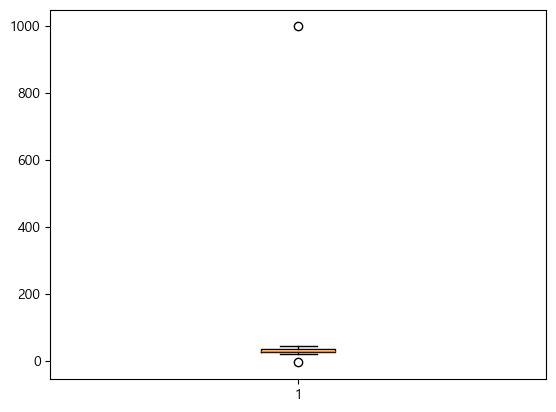

In [63]:
# age 이상치 있음
plt.boxplot(df1["age"].dropna())
plt.show()

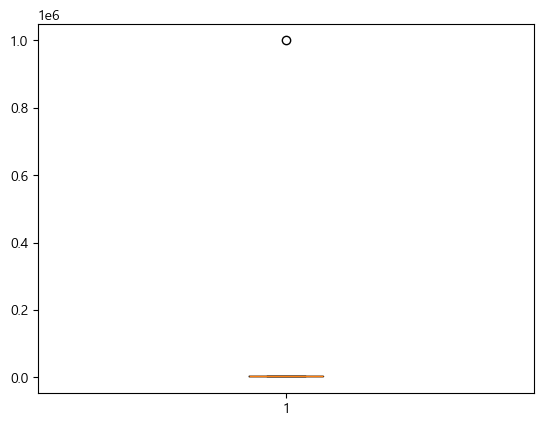

In [66]:
# salary 이상치 있음
plt.boxplot(df1["salary"].dropna())
plt.show()

In [68]:
# 1명의 중복 데이터가 있다
df1.duplicated(subset=["name", "age", "gender", "city"]).sum()

1

## 4단계. 결측치 대체

In [73]:
# age: 수치형
# - 평균, 중앙, 최빈
age_median = df1["age"].median()
df1["age"] = df1["age"].fillna(age_median)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [77]:
df1.loc[11]

id            12
name         이다은
age         29.0
gender         여
city          성남
salary    3900.0
Name: 11, dtype: object

In [81]:
df1["city"]

city_mode = df1["city"].mode()[0]
city_mode

'서울'

In [85]:
df1["city"] = df1["city"].fillna(city_mode)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [91]:
# salary 대체값 넣기 - 중앙값 사용
# 최빈값은 분류화를 할 때 사용을 해서 X
# 평균값은 이상치가 있어서 X
# 즉 중앙값을 활용하는 것이 가장 좋다
df1["salary"]
salary_median = df1["salary"].median()
df1["salary"] = df1["salary"].fillna(salary_median)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


## 컬럼의 형변환(astype)

In [97]:
df1["age"] = df1["age"].astype(int)
df1["salary"] = df1["salary"].astype(int)
df1

,id,name,age,gender,city,salary
0,1,김철수,28,남,서울,3500
1,2,이영희,31,여,부산,4200
2,3,박민수,25,남,대구,3000
3,4,최지은,29,여,인천,3800
4,5,정수현,34,남,광주,4500
5,6,한유진,27,여,대전,3600
6,7,오세훈,45,남,서울,5500
7,8,강민지,22,여,부산,2800
8,9,윤성호,38,남,울산,4900
9,10,송지수,26,여,서울,3400


## 5단계. 이상치 대체 또는 제거

In [104]:
Q1 = df1["salary"].quantile(0.25)
Q3 = df1["salary"].quantile(0.75)
IQR = Q3 - Q1
print(f"1사분위 값: {Q1}")
print(f"3사분위 값: {Q3}")
print(f"IQR: {IQR}")

1사분위 값: 3425.0
3사분위 값: 4475.0
IQR: 1050


In [108]:
min_outlier = Q1 - (IQR * 1.5)
max_outlier = Q3 + (IQR * 1.5)

print(f"max_outlier: {max_outlier} 초과는 이상치")
print(f"min_outlier: {min_outlier} 이하는 이상치")

max_outlier: 6050.0 초과는 이상치
min_outlier: 1850.0 이하는 이상치


In [112]:
outlier_mask = (df1["salary"] > max_outlier) | (df1["salary"] < min_outlier)
df1["salary"][outlier_mask]

27    999999
Name: salary, dtype: int32

In [114]:
# outlier 함수를 따로 만들기
def remove_outlier(df, col_name):
    df_copy = df.copy()

    Q1 = df_copy[col_name].quantile(0.25)
    Q3 = df_copy[col_name].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    mask = ~((df_copy[col_name] > upper) | (df_copy[col_name] < lower))

    return df_copy[mask]

In [120]:
df2 = remove_outlier(df1, "salary")
df3 = remove_outlier(df1, "age")

id        29
name      29
age       29
gender    29
city      29
salary    29
dtype: int64

In [122]:
# 중간에 빠진 고유값을 제거하고 1부터 끝까지 번호를 넣어줌
df4 = df3.reset_index(drop=True)
df4

,id,name,age,gender,city,salary
0,1,김철수,28,남,서울,3500
1,2,이영희,31,여,부산,4200
2,3,박민수,25,남,대구,3000
3,4,최지은,29,여,인천,3800
4,5,정수현,34,남,광주,4500
5,6,한유진,27,여,대전,3600
6,7,오세훈,45,남,서울,5500
7,8,강민지,22,여,부산,2800
8,9,윤성호,38,남,울산,4900
9,10,송지수,26,여,서울,3400


## 중복값 삭제

In [124]:
df4.duplicated(subset=["name", "age", "gender", "city"])

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15     True
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
dtype: bool

In [125]:
df4.drop_duplicates(subset=["name", "age", "gender", "city"]).reset_index(drop=True)

,id,name,age,gender,city,salary
0,1,김철수,28,남,서울,3500
1,2,이영희,31,여,부산,4200
2,3,박민수,25,남,대구,3000
3,4,최지은,29,여,인천,3800
4,5,정수현,34,남,광주,4500
5,6,한유진,27,여,대전,3600
6,7,오세훈,45,남,서울,5500
7,8,강민지,22,여,부산,2800
8,9,윤성호,38,남,울산,4900
9,10,송지수,26,여,서울,3400
